# Kidney Transplant Retain-Set Fine-Tuning

This notebook evaluates **retain-set fine-tuning** for five deterministic deletion requests. Each record is one synthetic longitudinal assessment, and the forward-looking target is acute rejection during the following 30 days—not kidney failure. All six assessments for a recipient and linked donor remain grouped.

Fine-tuning reloads the original model and continues ordinary training on retained records only. It does not explicitly erase forget records; it attempts to reduce their influence through retained-data updates. The original training-only preprocessor is frozen because this approximate method updates model parameters, not input statistics. Direct identifiers, provider identity, and protected attributes never become classifier inputs. This research evaluation is synthetic, is not formal unlearning certification, and is not a clinical decision system.

## 2. Imports, Configuration and Paths

This section reloads verified upstream artifacts. Hash checks prevent an approximate method from silently changing the dataset, split, original model, or full-retraining references.

In [1]:
from __future__ import annotations

import hashlib
import json
import platform
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import torch
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from scipy.stats import ks_2samp
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             brier_score_loss, confusion_matrix, f1_score, log_loss,
                             precision_score, recall_score, roc_auc_score)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
RANDOM_SEED = 42
METHOD = "retain_set_finetuning"
METHOD_DIRECTORY = "fine_tuning"
METHOD_CONFIG = {"seed": 42, "learning_rate": 0.0005, "maximum_epochs": 10, "batch_size": 128,
 "early_stopping_patience": 4, "early_stopping_min_delta": 0.0001,
 "optimizer": "Adam", "updated_parameters": "all_mlp_layers"}
EPSILON = 1e-7
BOOTSTRAP_REPETITIONS = 500
BOOTSTRAP_SEED = 2026
MEMBERSHIP_REPETITIONS = 20
MEMBERSHIP_SEED = 3030

# Seed every stochastic source so scenarios start from the same approved state.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Method: {METHOD} | device: {DEVICE}")

Method: retain_set_finetuning | device: mps


In [3]:
def locate_code_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        direct = candidate / "data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv"
        nested = candidate / "code/data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv"
        if direct.is_file(): return candidate
        if nested.is_file(): return candidate / "code"
    raise FileNotFoundError("Could not locate processed KidneyTransplant data.")

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

def index_hash(values: np.ndarray) -> str:
    return hashlib.sha256(np.asarray(values, dtype=np.int64).tobytes()).hexdigest()

CODE_ROOT = locate_code_root(Path.cwd().resolve())
DATA_PATH = CODE_ROOT / "data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv"
BASELINE_RESULTS = CODE_ROOT / "results/KidneyTransplant/baseline"
BASELINE_MODEL_PATH = CODE_ROOT / "models/KidneyTransplant/baseline/kidney_transplant_baseline_mlp.pt"
BASELINE_PREPROCESSOR_PATH = CODE_ROOT / "models/KidneyTransplant/baseline/kidney_transplant_preprocessor.joblib"
FULL_RESULTS = CODE_ROOT / "results/KidneyTransplant/full_retraining"
FULL_MODELS = CODE_ROOT / "models/KidneyTransplant/full_retraining"
RESULTS_ROOT = CODE_ROOT / f"results/KidneyTransplant/{METHOD_DIRECTORY}"
MODEL_ROOT = CODE_ROOT / f"models/KidneyTransplant/{METHOD_DIRECTORY}"

In [4]:
OUTPUT_DIRS = {name: RESULTS_ROOT / name for name in
               ["configuration", "histories", "metrics", "tables", "figures"]}
# Create destinations before training so no run depends on old output folders.
for directory in [MODEL_ROOT, *OUTPUT_DIRS.values()]: directory.mkdir(parents=True, exist_ok=True)

display(pd.DataFrame([
    {"artifact": "original model", "path": BASELINE_MODEL_PATH.relative_to(CODE_ROOT)},
    {"artifact": "full-retraining references", "path": FULL_MODELS.relative_to(CODE_ROOT)},
    {"artifact": f"{METHOD} models", "path": MODEL_ROOT.relative_to(CODE_ROOT)},
    {"artifact": f"{METHOD} results", "path": RESULTS_ROOT.relative_to(CODE_ROOT)},
]).style.hide(axis="index"))

artifact,path
original model,models/KidneyTransplant/baseline/kidney_transplant_baseline_mlp.pt
full-retraining references,models/KidneyTransplant/full_retraining
retain_set_finetuning models,models/KidneyTransplant/fine_tuning
retain_set_finetuning results,results/KidneyTransplant/fine_tuning


## 3. Artifact and Scenario Verification

The exact Notebook 02 indices are reused. Forget and retain sets cannot overlap, and their union must equal the original training set.

In [5]:
baseline_manifest = json.loads((BASELINE_RESULTS / "configuration/baseline_manifest.json").read_text())
full_manifest_path = FULL_RESULTS / "configuration/full_retraining_manifest.json"
full_manifest = json.loads(full_manifest_path.read_text())
baseline_checkpoint = torch.load(BASELINE_MODEL_PATH, map_location="cpu", weights_only=False)
baseline_preprocessor = joblib.load(BASELINE_PREPROCESSOR_PATH)
clean_df = pd.read_csv(DATA_PATH)

FEATURE_COLUMNS = baseline_checkpoint["feature_columns"]
EXCLUDED_COLUMNS = baseline_checkpoint["excluded_audit_columns"]
TARGET_COLUMN = baseline_checkpoint["target_column"]
THRESHOLD = float(baseline_checkpoint["fixed_baseline_validation_threshold"])
ARCHITECTURE = baseline_checkpoint["architecture"]
SCENARIOS = full_manifest["deletion_configuration"]
SCENARIO_NAMES = list(SCENARIOS)

assert sha256(DATA_PATH) == baseline_manifest["processed_dataset_hash"] == full_manifest["dataset_hash"]
assert THRESHOLD == full_manifest["threshold"]
assert set(EXCLUDED_COLUMNS).isdisjoint(FEATURE_COLUMNS)

In [6]:
split_indices = {name: np.load(CODE_ROOT / artifact["index_path"], allow_pickle=False)
                 for name, artifact in baseline_manifest["split_artifacts"].items()}
# Reuse baseline row positions; reconstructing them could change the experiment.
train_indices, validation_indices, test_indices = (split_indices[name] for name in ["train", "validation", "test"])
forget_indices = {name: np.load(FULL_RESULTS / f"indices/{name}_forget_indices.npy", allow_pickle=False)
                  for name in SCENARIO_NAMES}
retain_indices = {name: np.load(FULL_RESULTS / f"indices/{name}_retain_indices.npy", allow_pickle=False)
                  for name in SCENARIO_NAMES}

for name in SCENARIO_NAMES:
    assert set(forget_indices[name]).isdisjoint(retain_indices[name])
    assert set(forget_indices[name]) | set(retain_indices[name]) == set(train_indices)
    assert index_hash(forget_indices[name]) == full_manifest["index_hashes"][name]["forget"]
    assert index_hash(retain_indices[name]) == full_manifest["index_hashes"][name]["retain"]

In [7]:
features = clean_df[FEATURE_COLUMNS]
target = clean_df[TARGET_COLUMN].astype(int)
metadata = clean_df[["recipient_id", "donor_id", "hospital_id", "training_consent_version",
                     "assessment_date", "days_since_transplant", "donor_type"]].copy()
metadata["assessment_date"] = pd.to_datetime(metadata["assessment_date"], errors="raise")
metadata["derived_transplant_date"] = metadata["assessment_date"] - pd.to_timedelta(metadata["days_since_transplant"], unit="D")

def related_holdout_mask(frame, name):
    # Entity IDs cannot cross the grouped split; cohort rules still exclude related holdout populations.
    if name == "s3_hospital_withdrawal": return frame["hospital_id"].eq("H07")
    if name == "s4_invalid_consent": return frame["training_consent_version"].eq("RECIPIENT_V3")
    if name == "s5_retention_expiry":
        cutoff = metadata.loc[forget_indices[name], "derived_transplant_date"].max()
        return frame["derived_transplant_date"].le(cutoff)
    return pd.Series(False, index=frame.index)

In [8]:
scenario_data = {}
for name in SCENARIO_NAMES:
    # Exclude related cohorts from holdouts without changing the training forget request.
    validation_match = related_holdout_mask(metadata.loc[validation_indices], name)
    test_match = related_holdout_mask(metadata.loc[test_indices], name)
    scenario_data[name] = {
        "retain_train_x": features.loc[retain_indices[name]], "retain_train_y": target.loc[retain_indices[name]],
        "retain_validation_x": features.loc[validation_match.index[~validation_match]],
        "retain_validation_y": target.loc[validation_match.index[~validation_match]],
        "retain_test_x": features.loc[test_match.index[~test_match]],
        "retain_test_y": target.loc[test_match.index[~test_match]],
        "forget_x": features.loc[forget_indices[name]], "forget_y": target.loc[forget_indices[name]],
        "retain_validation_indices": validation_match.index[~validation_match].to_numpy(np.int64),
        "retain_test_indices": test_match.index[~test_match].to_numpy(np.int64),
        "forget_indices": forget_indices[name],
    }
verification = pd.DataFrame([{"scenario": name, "forget_rows": len(forget_indices[name]),
                              "retain_rows": len(retain_indices[name]),
                              "retained_validation_rows": len(scenario_data[name]["retain_validation_y"]),
                              "retained_test_rows": len(scenario_data[name]["retain_test_y"]), "indices_verified": True}
                             for name in SCENARIO_NAMES])
display(verification.style.hide(axis="index"))

scenario,forget_rows,retain_rows,retained_validation_rows,retained_test_rows,indices_verified
s1_recipient_withdrawal,420,41580,9000,9000,True
s2_living_donor_withdrawal,2100,39900,9000,9000,True
s3_hospital_withdrawal,4200,37800,8100,8100,True
s4_invalid_consent,4200,37800,8100,8100,True
s5_retention_expiry,6300,35700,7704,7692,True


## 4. Shared Model, Metrics and Truth Ratio

All approximate methods use identical utility and forget-quality definitions. KS D is the primary distribution distance; its p-value is supporting because it depends strongly on sample size and ignores natural row pairing.

In [9]:
class KidneyMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__(); h1, h2 = ARCHITECTURE["hidden_layer_dimensions"]
        self.network = nn.Sequential(nn.Linear(input_dim, h1), nn.ReLU(),
                                     nn.Dropout(ARCHITECTURE["dropout_probability"]),
                                     nn.Linear(h1, h2), nn.ReLU(), nn.Linear(h2, 1))
    def forward(self, values): return self.network(values).squeeze(1)

def load_model(checkpoint):
    # A fresh object prevents parameter updates leaking between scenarios.
    model = KidneyMLP(checkpoint["input_dim"]); model.load_state_dict(checkpoint["state_dict"])
    return model.to(DEVICE).eval()

def predict_raw(model, preprocessor, raw_features):
    processed = preprocessor.transform(raw_features).astype(np.float32)
    model.eval()
    with torch.no_grad(): logits = model(torch.tensor(processed, device=DEVICE))
    probabilities = torch.sigmoid(logits).cpu().numpy()
    assert np.isfinite(probabilities).all()
    return probabilities

In [10]:
def utility_metrics(labels, probabilities):
    # The validation-selected threshold remains fixed across every method and scenario.
    probabilities = np.clip(np.asarray(probabilities, float), EPSILON, 1 - EPSILON)
    predictions = probabilities >= THRESHOLD
    matrix = confusion_matrix(labels, predictions, labels=[0, 1]); tn, fp, fn, tp = matrix.ravel()
    return {"auroc": roc_auc_score(labels, probabilities), "pr_auc": average_precision_score(labels, probabilities),
            "brier_score": brier_score_loss(labels, probabilities), "bce": log_loss(labels, probabilities, labels=[0, 1]),
            "f1": f1_score(labels, predictions, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(labels, predictions),
            "precision": precision_score(labels, predictions, zero_division=0),
            "recall": recall_score(labels, predictions, zero_division=0),
            "specificity": tn / (tn + fp), "tn": tn, "fp": fp, "fn": fn, "tp": tp}

def classifier_truth_ratio(labels, probabilities):
    # Binary adaptation inspired by TOFU; this is not the original generative Truth Ratio.
    y = labels.to_numpy(float); p = np.clip(np.asarray(probabilities, float), EPSILON, 1 - EPSILON)
    p_correct = np.clip(y * p + (1 - y) * (1 - p), EPSILON, 1 - EPSILON)
    return (1 - p_correct) / p_correct

In [11]:
def forget_quality(labels, original, unlearned, reference):
    # KS compares distributions; MAE preserves the natural row pairing.
    before = ks_2samp(classifier_truth_ratio(labels, original), classifier_truth_ratio(labels, reference))
    after = ks_2samp(classifier_truth_ratio(labels, unlearned), classifier_truth_ratio(labels, reference))
    before_mae = np.abs(original - reference).mean(); after_mae = np.abs(unlearned - reference).mean()
    y = labels.to_numpy(float)
    confidence = lambda p: (y * p + (1 - y) * (1 - p)).mean()
    return {"ks_d_before": before.statistic, "ks_d_after": after.statistic,
            "ks_d_improvement": before.statistic - after.statistic, "ks_p_value_after": after.pvalue,
            "probability_mae_before": before_mae, "probability_mae_after": after_mae,
            "probability_mae_improvement": before_mae - after_mae,
            "prediction_agreement_after": ((unlearned >= THRESHOLD) == (reference >= THRESHOLD)).mean(),
            "absolute_bce_difference_after": abs(log_loss(labels, np.clip(unlearned, EPSILON, 1-EPSILON), labels=[0,1]) -
                                                 log_loss(labels, np.clip(reference, EPSILON, 1-EPSILON), labels=[0,1])),
            "absolute_confidence_difference_after": abs(confidence(unlearned) - confidence(reference)),
            "forget_rows": len(labels)}

In [12]:
def class_conditional_forget_quality(labels, original, unlearned, reference):
    rows = []
    for subset, class_value in [("all", None), ("target_0", 0), ("target_1", 1)]:
        mask = np.ones(len(labels), dtype=bool) if class_value is None else labels.to_numpy() == class_value
        count = int(mask.sum())
        if count < 20:
            rows.append({"subset": subset, "row_count": count, "ks_d_before": np.nan,
                         "ks_d_after": np.nan, "probability_mae_before": np.nan,
                         "probability_mae_after": np.nan})
            continue
        subset_labels = labels.iloc[np.flatnonzero(mask)]
        before = ks_2samp(classifier_truth_ratio(subset_labels, original[mask]),
                          classifier_truth_ratio(subset_labels, reference[mask])).statistic
        after = ks_2samp(classifier_truth_ratio(subset_labels, unlearned[mask]),
                         classifier_truth_ratio(subset_labels, reference[mask])).statistic
        rows.append({"subset": subset, "row_count": count, "ks_d_before": before, "ks_d_after": after,
                     "probability_mae_before": np.abs(original[mask]-reference[mask]).mean(),
                     "probability_mae_after": np.abs(unlearned[mask]-reference[mask]).mean()})
    return rows

In [13]:
def per_record_bce(labels, probabilities):
    y = np.asarray(labels, dtype=float); p = np.clip(np.asarray(probabilities, float), EPSILON, 1-EPSILON)
    return -(y*np.log(p) + (1-y)*np.log(1-p))

def matched_nonmember_indices(name, repeat):
    data = scenario_data[name]
    candidate_indices = np.concatenate([data["retain_validation_indices"], data["retain_test_indices"]])
    forget_frame = metadata.loc[data["forget_indices"]].assign(target=data["forget_y"].to_numpy())
    candidate_frame = metadata.loc[candidate_indices].assign(target=target.loc[candidate_indices].to_numpy())
    rng = np.random.default_rng(MEMBERSHIP_SEED + 100*SCENARIO_NAMES.index(name) + repeat)
    sampled = []
    for keys, group in forget_frame.groupby(["target", "days_since_transplant", "donor_type"], dropna=False):
        pool = candidate_frame.loc[(candidate_frame["target"].eq(keys[0])) &
                                   (candidate_frame["days_since_transplant"].eq(keys[1])) &
                                   (candidate_frame["donor_type"].eq(keys[2]))]
        if pool.empty:
            pool = candidate_frame.loc[(candidate_frame["target"].eq(keys[0])) &
                                       (candidate_frame["days_since_transplant"].eq(keys[1]))]
        if pool.empty: pool = candidate_frame.loc[candidate_frame["target"].eq(keys[0])]
        sampled.extend(rng.choice(pool.index.to_numpy(), size=len(group), replace=len(pool)<len(group)))
    return np.asarray(sampled, dtype=np.int64)

In [14]:
def membership_attack_summary(name, models, member_probabilities):
    member_labels = scenario_data[name]["forget_y"].to_numpy()
    member_scores = {model: -per_record_bce(member_labels, values)
                     for model, values in member_probabilities.items()}
    auc_rows = []
    for repeat in range(MEMBERSHIP_REPETITIONS):
        nonmember_indices = matched_nonmember_indices(name, repeat)
        nonmember_labels = target.loc[nonmember_indices].to_numpy()
        attack_labels = np.r_[np.ones(len(member_labels)), np.zeros(len(nonmember_labels))]
        for model_name, (model, preprocessor) in models.items():
            nonmember_prob = predict_raw(model, preprocessor, features.loc[nonmember_indices])
            scores = np.r_[member_scores[model_name], -per_record_bce(nonmember_labels, nonmember_prob)]
            auc_rows.append({"model": model_name, "repeat": repeat,
                             "attack_roc_auc": roc_auc_score(attack_labels, scores)})
    rows = pd.DataFrame(auc_rows)
    return rows.groupby("model")["attack_roc_auc"].agg(["mean", "std"]).reset_index()

In [15]:
def recipient_mae_bootstrap(name, original, unlearned, reference):
    recipients = metadata.loc[forget_indices[name], "recipient_id"].to_numpy()
    unique_recipients = np.unique(recipients)
    positions = {recipient: np.flatnonzero(recipients == recipient) for recipient in unique_recipients}
    rng = np.random.default_rng(BOOTSTRAP_SEED + SCENARIO_NAMES.index(name)); rows = []
    for _ in range(BOOTSTRAP_REPETITIONS):
        sampled = rng.choice(unique_recipients, size=len(unique_recipients), replace=True)
        selected = np.concatenate([positions[recipient] for recipient in sampled])
        before = np.abs(original[selected]-reference[selected]).mean()
        after = np.abs(unlearned[selected]-reference[selected]).mean()
        rows.append({"probability_mae_after": after, "probability_mae_improvement": before-after})
    return pd.DataFrame(rows)

## 5. Retain-Set Fine-Tuning Training

Checkpoint selection uses retained validation BCE only. Forget and test trajectories are diagnostic and cannot select the final checkpoint. This prevents test-driven unlearning.

In [16]:
def make_loader(raw_features, labels, shuffle):
    # Approximate methods keep the original transform instead of refitting on deletion data.
    processed = baseline_preprocessor.transform(raw_features).astype(np.float32)
    dataset = TensorDataset(torch.tensor(processed), torch.tensor(labels.to_numpy(), dtype=torch.float32))
    return DataLoader(dataset, batch_size=METHOD_CONFIG["batch_size"], shuffle=shuffle,
                      generator=torch.Generator().manual_seed(RANDOM_SEED))

def validation_bce(model, loader):
    model.eval(); criterion = nn.BCEWithLogitsLoss(); total = 0.0; rows = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            total += loss.item() * len(batch_y); rows += len(batch_y)
    return total / rows

full_checkpoints = {name: torch.load(FULL_MODELS / name / "model.pt", map_location="cpu", weights_only=False)
                    for name in SCENARIO_NAMES}
# Full-retraining models are evaluation targets only; they never supply gradients.
full_preprocessors = {name: joblib.load(FULL_MODELS / name / "preprocessor.joblib") for name in SCENARIO_NAMES}

In [17]:
def select_utility_constrained_ga_checkpoint(history, candidate_states):
    acceptable = history.loc[history["relative_validation_bce_increase"].le(
        METHOD_CONFIG["maximum_relative_validation_bce_increase"])]
    if len(acceptable):
        selected = acceptable.sort_values(["forget_loss", "epoch"], ascending=False).iloc[0]
        reason = "largest forget BCE among checkpoints within the 2% retained-validation utility constraint"
        constraint_satisfied = True
    else:
        selected = history.sort_values(["retained_validation_bce", "epoch"]).iloc[0]
        reason = "utility constraint failed; selected the least damaging post-update checkpoint"
        constraint_satisfied = False
    return selected, candidate_states[int(selected["epoch"])], reason, constraint_satisfied

In [18]:
def train_scenario(name):
    random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
    model = load_model(torch.load(BASELINE_MODEL_PATH, map_location="cpu", weights_only=False))
    data = scenario_data[name]
    train_loader = make_loader(data["retain_train_x"], data["retain_train_y"], True)
    validation_loader = make_loader(data["retain_validation_x"], data["retain_validation_y"], False)
    optimizer = torch.optim.Adam(model.parameters(), lr=METHOD_CONFIG["learning_rate"])
    criterion = nn.BCEWithLogitsLoss(); best_loss, best_state, stale, rows = float("inf"), None, 0, []
    reference_model = load_model(full_checkpoints[name])
    reference_forget = predict_raw(reference_model, full_preprocessors[name], data["forget_x"])
    started = time.perf_counter()
    # Retained validation alone governs early stopping; diagnostic forget metrics cannot select.
    for epoch in range(1, METHOD_CONFIG["maximum_epochs"] + 1):
        model.train(); loss_sum = 0.0; count = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad(); loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            loss.backward(); optimizer.step(); loss_sum += loss.item() * len(batch_y); count += len(batch_y)
        val_loss = validation_bce(model, validation_loader)
        val_prob = predict_raw(model, baseline_preprocessor, data["retain_validation_x"])
        forget_prob = predict_raw(model, baseline_preprocessor, data["forget_x"])
        ks = ks_2samp(classifier_truth_ratio(data["forget_y"], forget_prob),
                      classifier_truth_ratio(data["forget_y"], reference_forget)).statistic
        rows.append({"epoch": epoch, "retain_training_bce": loss_sum / count,
                     "retained_validation_bce": val_loss,
                     "retained_validation_pr_auc": average_precision_score(data["retain_validation_y"], val_prob),
                     "forget_loss": log_loss(data["forget_y"], np.clip(forget_prob, EPSILON, 1-EPSILON), labels=[0,1]),
                     "ks_d": ks, "probability_mae": np.abs(forget_prob-reference_forget).mean(),
                     "elapsed_seconds": time.perf_counter()-started})
        if val_loss < best_loss - METHOD_CONFIG["early_stopping_min_delta"]:
            best_loss, stale = val_loss, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else: stale += 1
        if stale >= METHOD_CONFIG["early_stopping_patience"]: break
    model.load_state_dict(best_state)
    return {"model": model, "history": pd.DataFrame(rows), "best_validation_bce": best_loss,
            "epochs_completed": epoch, "runtime_seconds": time.perf_counter()-started}

In [19]:
runs = {}
for name in SCENARIO_NAMES:
    # Each scenario reloads the canonical original inside train_scenario.
    runs[name] = train_scenario(name)
    selection = f", selected epoch {runs[name]['selected_epoch']}" if "selected_epoch" in runs[name] else ""
    print(f"{name}: {runs[name]['epochs_completed']} epochs{selection}, {runs[name]['runtime_seconds']:.2f} seconds")

trajectory = pd.concat([run["history"].assign(scenario=name) for name, run in runs.items()], ignore_index=True)
display(trajectory.style.hide(axis="index").format(precision=5))

s1_recipient_withdrawal: 7 epochs, 9.73 seconds


s2_living_donor_withdrawal: 6 epochs, 8.25 seconds


s3_hospital_withdrawal: 5 epochs, 6.58 seconds


s4_invalid_consent: 5 epochs, 6.28 seconds


s5_retention_expiry: 6 epochs, 7.13 seconds


epoch,retain_training_bce,retained_validation_bce,retained_validation_pr_auc,forget_loss,ks_d,probability_mae,elapsed_seconds,scenario
1,0.08877,0.09157,0.28571,0.06055,0.06429,0.00439,1.73819,s1_recipient_withdrawal
2,0.08872,0.09129,0.28871,0.06137,0.03095,0.00400,3.01749,s1_recipient_withdrawal
3,0.08822,0.09119,0.29501,0.06049,0.06667,0.00444,4.29735,s1_recipient_withdrawal
4,0.08797,0.09132,0.29032,0.06076,0.04524,0.00422,5.58936,s1_recipient_withdrawal
5,0.08813,0.09150,0.28781,0.06243,0.03095,0.00486,6.98874,s1_recipient_withdrawal
6,0.08790,0.09159,0.28875,0.06090,0.06429,0.00415,8.45095,s1_recipient_withdrawal
7,0.08813,0.09178,0.28875,0.06282,0.02619,0.00514,9.73002,s1_recipient_withdrawal
1,0.09060,0.09163,0.28656,0.05298,0.07714,0.00379,1.46051,s2_living_donor_withdrawal
2,0.09018,0.09131,0.28937,0.05219,0.08238,0.00380,2.81382,s2_living_donor_withdrawal
3,0.08997,0.09179,0.28367,0.05264,0.06810,0.00390,4.16783,s2_living_donor_withdrawal


The trajectory shows utility protection and movement toward or away from the full-retraining forget behaviour. It is descriptive; no universal KS pass threshold is imposed.

## 6. Retained Utility

Original, approximate, and full-retraining models use identical retained-test rows and the unchanged validation-selected threshold. Test data never select a checkpoint.

In [20]:
baseline_model = load_model(baseline_checkpoint)
prediction_cache, utility_rows = {}, []
for name in SCENARIO_NAMES:
    data = scenario_data[name]; reference_model = load_model(full_checkpoints[name])
    # All three models see the same retained-test records for a fair comparison.
    probabilities = {
        "original": predict_raw(baseline_model, baseline_preprocessor, data["retain_test_x"]),
        METHOD: predict_raw(runs[name]["model"], baseline_preprocessor, data["retain_test_x"]),
        "full_retraining": predict_raw(reference_model, full_preprocessors[name], data["retain_test_x"]),
    }
    prediction_cache[name] = probabilities
    for model_name, values in probabilities.items():
        utility_rows.append({"scenario": name, "model": model_name, "retained_test_rows": len(data["retain_test_y"]),
                             "threshold": THRESHOLD, **utility_metrics(data["retain_test_y"], values)})
utility = pd.DataFrame(utility_rows)
display(utility[["scenario", "model", "retained_test_rows", "threshold", "pr_auc", "recall",
                 "precision", "brier_score"]].style.hide(axis="index").format(precision=4))

scenario,model,retained_test_rows,threshold,pr_auc,recall,precision,brier_score
s1_recipient_withdrawal,original,9000,0.0700,0.2819,0.6129,0.1823,0.0230
s1_recipient_withdrawal,retain_set_finetuning,9000,0.0700,0.2844,0.5605,0.1947,0.0230
s1_recipient_withdrawal,full_retraining,9000,0.0700,0.2882,0.6129,0.1790,0.0229
s2_living_donor_withdrawal,original,9000,0.0700,0.2819,0.6129,0.1823,0.0230
s2_living_donor_withdrawal,retain_set_finetuning,9000,0.0700,0.2847,0.5927,0.1804,0.0229
s2_living_donor_withdrawal,full_retraining,9000,0.0700,0.2927,0.6250,0.1701,0.0229
s3_hospital_withdrawal,original,8100,0.0700,0.2688,0.6308,0.1779,0.0223
s3_hospital_withdrawal,retain_set_finetuning,8100,0.0700,0.2699,0.6262,0.1784,0.0223
s3_hospital_withdrawal,full_retraining,8100,0.0700,0.2653,0.5888,0.1645,0.0223
s4_invalid_consent,original,8100,0.0700,0.2819,0.6101,0.1819,0.0224


PR-AUC, frozen-threshold recall and precision, and Brier score are the main utility results. AUROC, F1 and balanced accuracy remain saved as supplementary diagnostics rather than headline evidence.

## 7. Forget Quality Against Full Retraining

Truth Ratio below 1 favours the observed class, 1 gives equal class probability, and above 1 favours the other class. Lower KS D and probability MAE mean closer behavioural similarity to full retraining.

In [21]:
forget_rows, conditional_rows, bootstrap_rows, forget_prediction_cache = [], [], [], {}
for name in SCENARIO_NAMES:
    data = scenario_data[name]; reference_model = load_model(full_checkpoints[name])
    # The exact Notebook 02 forget rows and labels are shared by every method.
    original = predict_raw(baseline_model, baseline_preprocessor, data["forget_x"])
    unlearned = predict_raw(runs[name]["model"], baseline_preprocessor, data["forget_x"])
    reference = predict_raw(reference_model, full_preprocessors[name], data["forget_x"])
    main_metrics = forget_quality(data["forget_y"], original, unlearned, reference)
    main_metrics["probability_mae_percentage_change"] = (
        100*main_metrics["probability_mae_improvement"]/main_metrics["probability_mae_before"]
        if main_metrics["probability_mae_before"] > 0 else np.nan)
    forget_rows.append({"scenario": name, "method": METHOD, **main_metrics})
    conditional_rows.extend({"scenario": name, "method": METHOD, **row}
                            for row in class_conditional_forget_quality(
                                data["forget_y"], original, unlearned, reference))
    forget_prediction_cache[name] = {"original": original, METHOD: unlearned,
                                     "full_retraining": reference}
    samples = recipient_mae_bootstrap(name, original, unlearned, reference)
    bootstrap_rows.append({"scenario": name, "method": METHOD,
        "probability_mae_after_ci_lower": samples["probability_mae_after"].quantile(.025),
        "probability_mae_after_ci_upper": samples["probability_mae_after"].quantile(.975),
        "probability_mae_improvement_ci_lower": samples["probability_mae_improvement"].quantile(.025),
        "probability_mae_improvement_ci_upper": samples["probability_mae_improvement"].quantile(.975),
        "valid_repetitions": len(samples)})
forget_metrics = pd.DataFrame(forget_rows)
class_conditional_forget_metrics = pd.DataFrame(conditional_rows)
mae_bootstrap_intervals = pd.DataFrame(bootstrap_rows)
forget_metrics = forget_metrics.merge(mae_bootstrap_intervals, on=["scenario", "method"], validate="one_to_one")

In [22]:
membership_rows = []
for name in SCENARIO_NAMES:
    reference_model = load_model(full_checkpoints[name])
    models = {"original": (baseline_model, baseline_preprocessor),
              METHOD: (runs[name]["model"], baseline_preprocessor),
              "full_retraining": (reference_model, full_preprocessors[name])}
    membership = membership_attack_summary(name, models, forget_prediction_cache[name])
    membership_rows.extend({"scenario": name, **row} for row in membership.to_dict("records"))
membership_attack = pd.DataFrame(membership_rows)
attack_wide = membership_attack.pivot(index="scenario", columns="model", values="mean")
forget_metrics["membership_attack_auc_before"] = forget_metrics["scenario"].map(attack_wide["original"])
forget_metrics["membership_attack_auc_after"] = forget_metrics["scenario"].map(attack_wide[METHOD])
forget_metrics["membership_attack_auc_reference"] = forget_metrics["scenario"].map(attack_wide["full_retraining"])
def executed_result_label(row):
    if row["ks_d_improvement"] > 0 and row["probability_mae_improvement_ci_lower"] > 0:
        return "improved"
    if row["ks_d_improvement"] < 0 and row["probability_mae_improvement_ci_upper"] < 0:
        return "worsened"
    if row["ks_d_improvement"] == 0 and row["probability_mae_improvement_ci_lower"] <= 0 <= row["probability_mae_improvement_ci_upper"]:
        return "unchanged"
    return "mixed"
forget_metrics["result_label"] = forget_metrics.apply(executed_result_label, axis=1)
display(forget_metrics.style.hide(axis="index").format(precision=5))
display(class_conditional_forget_metrics.style.hide(axis="index").format(precision=5))
display(membership_attack.style.hide(axis="index").format(precision=5))
insufficient = class_conditional_forget_metrics.loc[
    class_conditional_forget_metrics["row_count"].lt(20), ["scenario", "subset", "row_count"]]
if len(insufficient):
    display(Markdown("**Insufficient class-specific sample:** " + "; ".join(
        f"{row.scenario} {row.subset} has {row.row_count} rows" for row in insufficient.itertuples()
    ) + ". KS D and probability MAE are intentionally `NaN`."))

scenario,method,ks_d_before,ks_d_after,ks_d_improvement,ks_p_value_after,probability_mae_before,probability_mae_after,probability_mae_improvement,prediction_agreement_after,absolute_bce_difference_after,absolute_confidence_difference_after,forget_rows,probability_mae_percentage_change,probability_mae_after_ci_lower,probability_mae_after_ci_upper,probability_mae_improvement_ci_lower,probability_mae_improvement_ci_upper,valid_repetitions,membership_attack_auc_before,membership_attack_auc_after,membership_attack_auc_reference,result_label
s1_recipient_withdrawal,retain_set_finetuning,0.03095,0.06667,-0.03571,0.30841,0.00357,0.00444,-0.00087,0.98571,0.00554,0.00346,420,-24.22149,0.00324,0.00577,-0.00150,-0.00028,500,0.49696,0.49705,0.49737,worsened
s2_living_donor_withdrawal,retain_set_finetuning,0.07238,0.08238,-0.01000,0.00000,0.00334,0.00380,-0.00046,0.99095,0.00290,0.00191,2100,-13.75506,0.00321,0.00454,-0.00065,-0.00030,500,0.49820,0.49842,0.49844,worsened
s3_hospital_withdrawal,retain_set_finetuning,0.02690,0.00881,0.01810,0.99680,0.00507,0.00500,0.00007,0.98119,0.00595,0.00105,4200,1.40494,0.00439,0.00559,-0.00010,0.00023,500,0.50754,0.50772,0.50728,mixed
s4_invalid_consent,retain_set_finetuning,0.02500,0.05500,-0.03000,0.00001,0.00541,0.00559,-0.00018,0.98000,0.00499,0.00399,4200,-3.36661,0.00504,0.00620,-0.00039,0.00002,500,0.50102,0.50029,0.49711,mixed
s5_retention_expiry,retain_set_finetuning,0.01603,0.02587,-0.00984,0.02947,0.00574,0.00568,0.00006,0.98206,0.00514,0.00161,6300,1.09147,0.00524,0.00622,-0.00010,0.00021,500,0.51107,0.51217,0.50856,mixed


scenario,method,subset,row_count,ks_d_before,ks_d_after,probability_mae_before,probability_mae_after
s1_recipient_withdrawal,retain_set_finetuning,all,420,0.03095,0.06667,0.00357,0.00444
s1_recipient_withdrawal,retain_set_finetuning,target_0,412,0.03155,0.06796,0.00313,0.00392
s1_recipient_withdrawal,retain_set_finetuning,target_1,8,nan,nan,nan,nan
s2_living_donor_withdrawal,retain_set_finetuning,all,2100,0.07238,0.08238,0.00334,0.00380
s2_living_donor_withdrawal,retain_set_finetuning,target_0,2072,0.07336,0.08349,0.00307,0.00347
s2_living_donor_withdrawal,retain_set_finetuning,target_1,28,0.10714,0.10714,0.02322,0.02816
s3_hospital_withdrawal,retain_set_finetuning,all,4200,0.02690,0.00881,0.00507,0.00500
s3_hospital_withdrawal,retain_set_finetuning,target_0,4069,0.02777,0.00909,0.00408,0.00395
s3_hospital_withdrawal,retain_set_finetuning,target_1,131,0.09160,0.09160,0.03583,0.03748
s4_invalid_consent,retain_set_finetuning,all,4200,0.02500,0.05500,0.00541,0.00559


scenario,model,mean,std
s1_recipient_withdrawal,full_retraining,0.49737,0.01253
s1_recipient_withdrawal,original,0.49696,0.01321
s1_recipient_withdrawal,retain_set_finetuning,0.49705,0.01299
s2_living_donor_withdrawal,full_retraining,0.49844,0.00356
s2_living_donor_withdrawal,original,0.49820,0.00354
s2_living_donor_withdrawal,retain_set_finetuning,0.49842,0.00355
s3_hospital_withdrawal,full_retraining,0.50728,0.00293
s3_hospital_withdrawal,original,0.50754,0.00289
s3_hospital_withdrawal,retain_set_finetuning,0.50772,0.00297
s4_invalid_consent,full_retraining,0.49711,0.00427


**Insufficient class-specific sample:** s1_recipient_withdrawal target_1 has 8 rows. KS D and probability MAE are intentionally `NaN`.

Positive-class rows below 20 are reported as `NaN` with an insufficient-sample warning; they are not treated as reliable evidence. The loss-based membership attack uses 20 fixed-seed target/stage/donor-matched nonmember samples. AUC near 0.50 means weak distinguishability, not proof of deletion. KS p-values and prediction agreement remain supplementary, and behavioural similarity does not prove certified deletion.

## 8. Runtime and Speed-Up

The method runtime starts immediately before parameter updates and ends after checkpoint restoration. Full-retraining runtimes use the same device-recorded Notebook 02 boundaries.

In [23]:
full_runtime = pd.read_csv(FULL_RESULTS / "tables/training_summary.csv").set_index("scenario")
runtime = pd.DataFrame([{
    "scenario": name, "method_runtime_seconds": runs[name]["runtime_seconds"],
    "full_retraining_runtime_seconds": float(full_runtime.loc[name, "runtime_seconds"]),
    "seconds_saved": float(full_runtime.loc[name, "runtime_seconds"]) - runs[name]["runtime_seconds"],
    "speed_up_full_over_method": float(full_runtime.loc[name, "runtime_seconds"]) / runs[name]["runtime_seconds"],
    "method_epochs": runs[name]["epochs_completed"],
} for name in SCENARIO_NAMES])
display(runtime.style.hide(axis="index").format({"method_runtime_seconds":"{:.2f}",
    "full_retraining_runtime_seconds":"{:.2f}", "seconds_saved":"{:+.2f}", "speed_up_full_over_method":"{:.2f}×"}))

scenario,method_runtime_seconds,full_retraining_runtime_seconds,seconds_saved,speed_up_full_over_method,method_epochs
s1_recipient_withdrawal,9.73,36.94,+27.21,3.80×,7
s2_living_donor_withdrawal,8.25,28.04,+19.79,3.40×,6
s3_hospital_withdrawal,6.58,26.19,+19.61,3.98×,5
s4_invalid_consent,6.28,28.53,+22.25,4.54×,5
s5_retention_expiry,7.13,22.48,+15.35,3.15×,6


## 9. Comparative Figures

Consistent scenario ordering and shared axes make utility, forgetting, and efficiency trade-offs comparable.

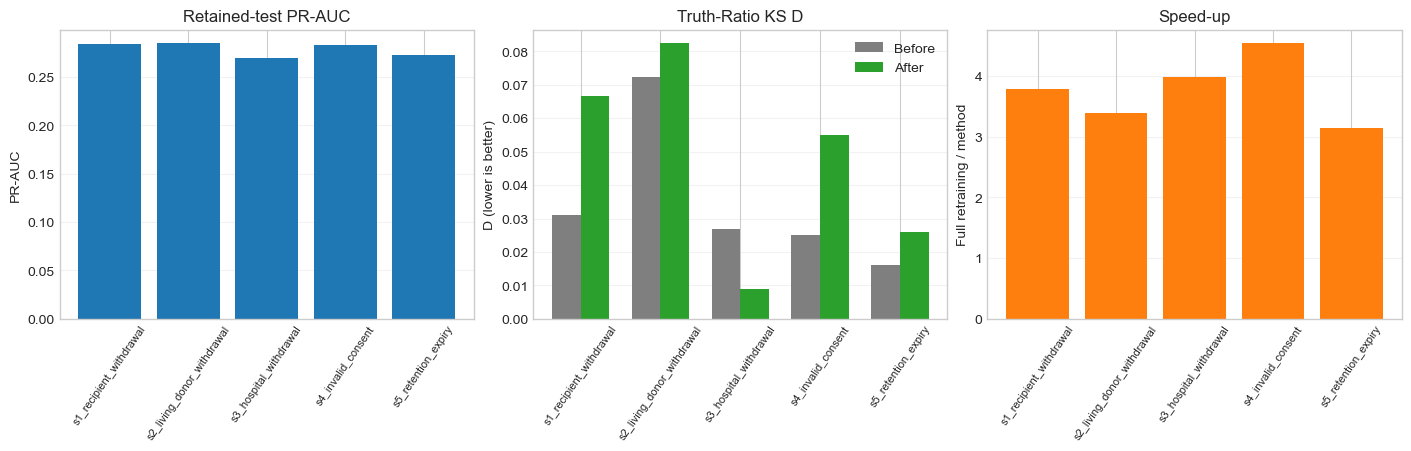

In [24]:
comparison_figure, axes = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True)
method_utility = utility.query("model == @METHOD")
axes[0].bar(method_utility["scenario"], method_utility["pr_auc"], color="#1f77b4")
axes[0].set(title="Retained-test PR-AUC", ylabel="PR-AUC")
x = np.arange(len(forget_metrics)); width = 0.36
axes[1].bar(x-width/2, forget_metrics["ks_d_before"], width, label="Before", color="#7f7f7f")
axes[1].bar(x+width/2, forget_metrics["ks_d_after"], width, label="After", color="#2ca02c")
axes[1].set(title="Truth-Ratio KS D", ylabel="D (lower is better)", xticks=x,
            xticklabels=forget_metrics["scenario"]); axes[1].legend()
axes[2].bar(runtime["scenario"], runtime["speed_up_full_over_method"], color="#ff7f0e")
axes[2].set(title="Speed-up", ylabel="Full retraining / method")
for axis in axes: axis.tick_params(axis="x", rotation=55, labelsize=8); axis.grid(axis="y", alpha=0.25)
display(comparison_figure); plt.close(comparison_figure)

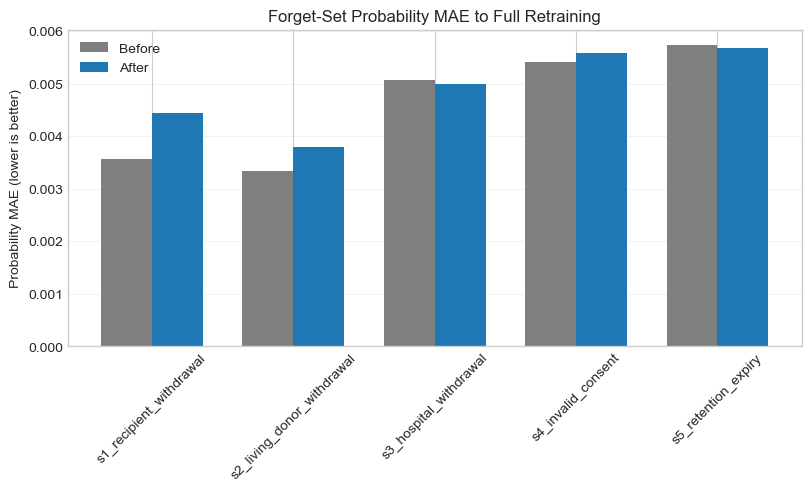

In [25]:
mae_figure, mae_axis = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
x = np.arange(len(forget_metrics)); width = 0.36
mae_axis.bar(x-width/2, forget_metrics["probability_mae_before"], width, label="Before", color="#7f7f7f")
mae_axis.bar(x+width/2, forget_metrics["probability_mae_after"], width, label="After", color="#1f77b4")
mae_axis.set(title="Forget-Set Probability MAE to Full Retraining", ylabel="Probability MAE (lower is better)",
             xticks=x, xticklabels=forget_metrics["scenario"])
mae_axis.tick_params(axis="x", rotation=45); mae_axis.legend(); mae_axis.grid(axis="y", alpha=0.25)
display(mae_figure); plt.close(mae_figure)

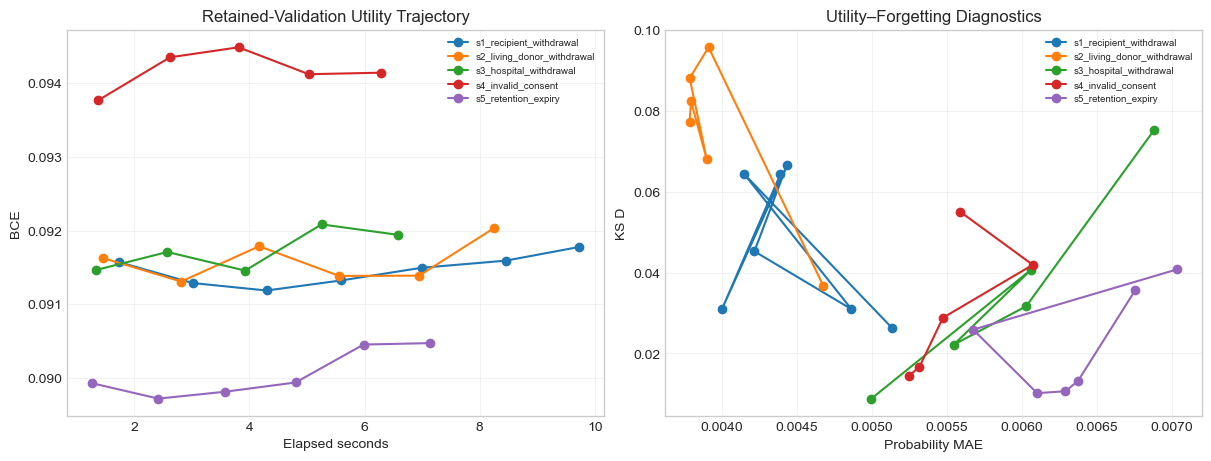

In [26]:
trajectory_figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for name in SCENARIO_NAMES:
    rows = trajectory.query("scenario == @name")
    axes[0].plot(rows["elapsed_seconds"], rows["retained_validation_bce"], marker="o", label=name)
    axes[1].plot(rows["probability_mae"], rows["ks_d"], marker="o", label=name)
axes[0].set(title="Retained-Validation Utility Trajectory", xlabel="Elapsed seconds", ylabel="BCE")
axes[1].set(title="Utility–Forgetting Diagnostics", xlabel="Probability MAE", ylabel="KS D")
for axis in axes: axis.grid(alpha=0.25); axis.legend(fontsize=7)
display(trajectory_figure); plt.close(trajectory_figure)

## 10. Centralised Saving

Saving after all scenarios avoids partially persisted training loops. Source hashes and index hashes preserve provenance.

In [27]:
training_rows = []
for name, run in runs.items():
    row = {"scenario": name, "seed": RANDOM_SEED, "epochs_completed": run["epochs_completed"],
           "selected_retained_validation_bce": run["best_validation_bce"],
           "runtime_seconds": run["runtime_seconds"]}
    if "selected_epoch" in run:
        row.update({"selected_epoch": run["selected_epoch"],
                    "selection_reason": run["selection_reason"],
                    "utility_constraint_satisfied": run["utility_constraint_satisfied"],
                    "best_forgetting_diagnostic_epoch": run["best_forgetting_diagnostic_epoch"],
                    "retained_validation_bce_change": run["best_validation_bce"]-run["original_validation_bce"],
                    "forget_bce_change": run["selected_forget_bce"]-run["original_forget_bce"]})
    training_rows.append(row)
training_summary = pd.DataFrame(training_rows)
TABLES = {
    "scenario_summary": (verification, OUTPUT_DIRS["tables"] / "scenario_summary.csv"),
    "training_summary": (training_summary, OUTPUT_DIRS["tables"] / "training_summary.csv"),
    "trajectory": (trajectory, OUTPUT_DIRS["histories"] / "checkpoint_trajectories.csv"),
    "utility": (utility, OUTPUT_DIRS["metrics"] / "utility_metrics.csv"),
    "forget": (forget_metrics, OUTPUT_DIRS["metrics"] / "forget_quality_metrics.csv"),
    "class_conditional_forget": (class_conditional_forget_metrics, OUTPUT_DIRS["metrics"] / "class_conditional_forget_metrics.csv"),
    "membership_attack": (membership_attack, OUTPUT_DIRS["metrics"] / "membership_attack_metrics.csv"),
    "mae_bootstrap": (mae_bootstrap_intervals, OUTPUT_DIRS["metrics"] / "probability_mae_bootstrap_intervals.csv"),
    "runtime": (runtime, OUTPUT_DIRS["tables"] / "runtime_metrics.csv"),
}
for frame, path in TABLES.values(): frame.to_csv(path, index=False)

In [28]:
MODEL_PATHS = {}
for name, run in runs.items():
    # CPU weights keep checkpoints portable across accelerator availability.
    model_dir = MODEL_ROOT / name; model_dir.mkdir(parents=True, exist_ok=True)
    path = model_dir / "model.pt"; MODEL_PATHS[name] = path
    payload = {"state_dict": {k: v.detach().cpu() for k, v in run["model"].state_dict().items()},
               "input_dim": baseline_checkpoint["input_dim"], "architecture": ARCHITECTURE,
               "method": METHOD, "scenario": name, "seed": RANDOM_SEED, "configuration": METHOD_CONFIG,
               "threshold": THRESHOLD, "source_baseline_hash": sha256(BASELINE_MODEL_PATH),
               "baseline_preprocessor_hash": sha256(BASELINE_PREPROCESSOR_PATH),
               "forget_index_hash": index_hash(forget_indices[name]), "retain_index_hash": index_hash(retain_indices[name])}
    if "selected_epoch" in run:
        payload.update({"selected_epoch": run["selected_epoch"], "selection_reason": run["selection_reason"],
                        "utility_constraint_satisfied": run["utility_constraint_satisfied"],
                        "best_forgetting_diagnostic_epoch": run["best_forgetting_diagnostic_epoch"]})
    torch.save(payload, path)

In [29]:
FIGURES = {"comparison": OUTPUT_DIRS["figures"] / "utility_ks_runtime.png",
           "probability_mae": OUTPUT_DIRS["figures"] / "probability_mae_before_after.png",
           "trajectory": OUTPUT_DIRS["figures"] / "utility_forgetting_trajectories.png"}
comparison_figure.savefig(FIGURES["comparison"], dpi=300, bbox_inches="tight")
mae_figure.savefig(FIGURES["probability_mae"], dpi=300, bbox_inches="tight")
trajectory_figure.savefig(FIGURES["trajectory"], dpi=300, bbox_inches="tight")

manifest = {"method": METHOD, "dataset_path": str(DATA_PATH.relative_to(CODE_ROOT)), "dataset_hash": sha256(DATA_PATH),
            "dataset_description": "Entirely synthetic longitudinal kidney-transplant follow-up assessments.",
            "target": TARGET_COLUMN, "feature_list": FEATURE_COLUMNS, "excluded_audit_fields": EXCLUDED_COLUMNS,
            "split_strategy": baseline_manifest["split_strategy"], "group_key": "recipient_id", "seeds": [RANDOM_SEED],
            "threshold": THRESHOLD, "threshold_label": "fixed_baseline_validation_threshold",
            "loss_choice": "BCEWithLogitsLoss", "deletion_configuration": SCENARIOS,
            "index_hashes": full_manifest["index_hashes"], "preprocessing_policy": "frozen original training-only preprocessor",
            "configuration": METHOD_CONFIG,
            "bootstrap_configuration": {"unit": "recipient_id", "seed": BOOTSTRAP_SEED,
                                        "repetitions": BOOTSTRAP_REPETITIONS, "confidence_level": 0.95},
            "membership_attack_configuration": {"score": "negative_per_record_bce", "seed": MEMBERSHIP_SEED,
                                                "matched_sampling_repetitions": MEMBERSHIP_REPETITIONS,
                                                "matching": ["target", "days_since_transplant", "donor_type"]},
            "runtime_environment": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
                                    "scipy": scipy.__version__, "scikit_learn": sklearn.__version__,
                                    "pytorch": torch.__version__, "device": str(DEVICE)}, "artifact_hashes": {}}
MANIFEST_PATH = OUTPUT_DIRS["configuration"] / "artifact_manifest.json"

In [30]:
artifact_paths = [*[path for _, path in TABLES.values()], *MODEL_PATHS.values(), *FIGURES.values()]
# Hash established outputs so later audits detect accidental replacement.
manifest["artifact_hashes"] = {str(path.relative_to(CODE_ROOT)): sha256(path) for path in artifact_paths}
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2))
print(f"Saved {METHOD} artifacts and manifest.")

Saved retain_set_finetuning artifacts and manifest.


## 11. Reload and Verification

Reloaded checkpoints must reproduce saved predictions and metrics. This tests persistence rather than trusting in-memory objects.

In [31]:
for frame, path in TABLES.values():
    # Numeric reload checks prove persistence rather than trusting memory.
    saved = pd.read_csv(path); assert saved.columns.tolist() == frame.columns.tolist() and len(saved) == len(frame)
    for column in frame.select_dtypes(include=np.number): assert np.allclose(saved[column], frame[column], equal_nan=True)

for name, path in MODEL_PATHS.items():
    saved = torch.load(path, map_location="cpu", weights_only=False)
    assert saved["source_baseline_hash"] == sha256(BASELINE_MODEL_PATH)
    assert saved["forget_index_hash"] == index_hash(forget_indices[name])
    reloaded = load_model(saved)
    sample = scenario_data[name]["retain_test_x"].iloc[:32]
    assert np.allclose(predict_raw(reloaded, baseline_preprocessor, sample),
                       predict_raw(runs[name]["model"], baseline_preprocessor, sample), rtol=1e-6, atol=1e-7)
assert json.loads(MANIFEST_PATH.read_text()) == manifest
assert all(sha256(CODE_ROOT / path) == digest for path, digest in manifest["artifact_hashes"].items())
print("All checkpoints, predictions, metrics, figures and manifest reloaded successfully.")

All checkpoints, predictions, metrics, figures and manifest reloaded successfully.


## 12. Final Discussion

In [32]:
label_summary = "; ".join(
    f"{row.scenario}: {row.result_label}" for row in forget_metrics[["scenario", "result_label"]].itertuples()
)
display(Markdown(
    "- **Utility:** retained-test metrics use identical rows and the fixed threshold.\n"
    "- **Forget quality:** KS D and paired probability MAE are primary; p-values, agreement, BCE and confidence are supplementary.\n"
    f"- **Executed scenario assessment:** {label_summary}.\n"
    "- **Efficiency:** runtime is compared with the corresponding full-retraining reference.\n"
    "- **Interpretation:** Retain-set fine-tuning can preserve utility efficiently, but it only indirectly addresses forgotten records. Its closeness to full retraining must therefore be judged from the executed KS D and paired probability MAE results. Faster runtime or preserved utility alone is not evidence of successful unlearning.\n"
    "- **Limitations:** synthetic data, one architecture, behavioural evaluation only, and no formal deletion guarantee."
))

- **Utility:** retained-test metrics use identical rows and the fixed threshold.
- **Forget quality:** KS D and paired probability MAE are primary; p-values, agreement, BCE and confidence are supplementary.
- **Executed scenario assessment:** s1_recipient_withdrawal: worsened; s2_living_donor_withdrawal: worsened; s3_hospital_withdrawal: mixed; s4_invalid_consent: mixed; s5_retention_expiry: mixed.
- **Efficiency:** runtime is compared with the corresponding full-retraining reference.
- **Interpretation:** Retain-set fine-tuning can preserve utility efficiently, but it only indirectly addresses forgotten records. Its closeness to full retraining must therefore be judged from the executed KS D and paired probability MAE results. Faster runtime or preserved utility alone is not evidence of successful unlearning.
- **Limitations:** synthetic data, one architecture, behavioural evaluation only, and no formal deletion guarantee.